In [19]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

In [20]:
master = pd.read_csv("../data/final/master_dataset_featured.csv")

print("Shape :",master.shape)

master.head()

Shape : (345374, 40)


,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield,Start_Year,Year_yield,Area_yield,Production_yield,fertilizer,pesticide,Yield_yield,Year_weather,avg_temp_c,total_rainfall_mm,avg_humidity_percent,N,P,K,pH,End_Year,Decade,Year_Group,Rainfall_Category,Temperature_Category,Humidity_Category,Production_per_Hectare,Fertilizer_per_Hectare,Pesticide_per_Hectare,Rainfall_per_Hectare,Crop_Category,Production_Level,Yield_Level,Weather_Data_Available,Soil_Data_Available
0,Andaman And Nicobar Islands,Nicobars,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2002,2000,2001-2005,NaN,NaN,NaN,1.643541,NaN,NaN,NaN,Other,Medium,Medium,False,False
1,Andaman And Nicobar Islands,Nicobars,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,2000,2001-2005,NaN,NaN,NaN,1.655803,NaN,NaN,NaN,Other,Medium,Medium,False,False
2,Andaman And Nicobar Islands,Nicobars,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004,2000,2001-2005,NaN,NaN,NaN,1.209358,NaN,NaN,NaN,Other,Medium,Medium,False,False
3,Andaman And Nicobar Islands,North And Middle Andaman,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2002,2000,2001-2005,NaN,NaN,NaN,1.690000,NaN,NaN,NaN,Other,High,Medium,False,False
4,Andaman And Nicobar Islands,South Andamans,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,2000,2001-2005,NaN,NaN,NaN,1.696296,NaN,NaN,NaN,Other,High,Medium,False,False


In [21]:
print("="*70)
print("DATASET INFORMATION")
print("="*70)

print()

master.info()

DATASET INFORMATION

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345374 entries, 0 to 345373
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   State                   345374 non-null  object 
 1   District                345374 non-null  object 
 2   Crop                    345374 non-null  object 
 3   Year                    345374 non-null  object 
 4   Season                  345374 non-null  object 
 5   Area                    345374 non-null  float64
 6   Area Units              345374 non-null  object 
 7   Production              340414 non-null  float64
 8   Production Units        345374 non-null  object 
 9   Yield                   345374 non-null  float64
 10  Start_Year              345374 non-null  int64  
 11  Year_yield              318023 non-null  float64
 12  Area_yield              318023 non-null  float64
 13  Production_yield        318023 non-null  float64
 14 

In [22]:
master.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State,345374,36,Uttar Pradesh,44781,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,345374,728,Bilaspur,1244,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,345374,56,Rice,21611,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,345374,24,2019-20,19264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,345374,6,Kharif,138388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,345374.0,NaN,NaN,NaN,11670.191258,45838.426638,0.004,74.0,532.0,4110.0,8580100.0
Area Units,345374,1,Hectare,345374,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Production,340414.0,NaN,NaN,NaN,958371.148664,21529855.088424,0.0,87.0,717.0,7176.0,1597800000.0
Production Units,345374,3,Tonnes,331653,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Yield,345374.0,NaN,NaN,NaN,79.407569,916.628744,0.0,0.546742,1.0,2.46708,43958.333333


In [23]:
missing=pd.DataFrame({

    "Missing Values":master.isnull().sum(),

    "Percentage":(
        master.isnull().mean()*100
    ).round(2)

})

missing=missing[
    missing["Missing Values"]>0
]

missing.sort_values(
    "Percentage",
    ascending=False
)

,Missing Values,Percentage
Fertilizer_per_Hectare,27351,7.92
Area_yield,27351,7.92
Production_yield,27351,7.92
fertilizer,27351,7.92
pesticide,27351,7.92
Yield_yield,27351,7.92
Pesticide_per_Hectare,27351,7.92
Year_yield,27351,7.92
Rainfall_Category,21889,6.34
pH,21587,6.25


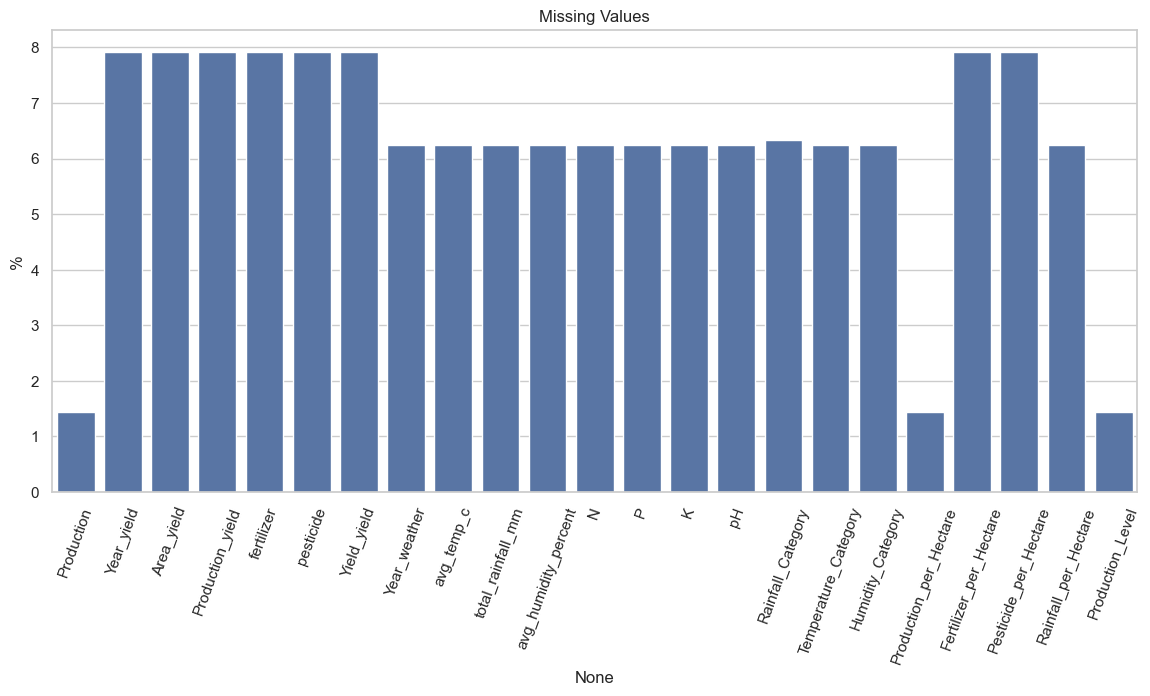

In [24]:
plt.figure(figsize=(14,6))

sns.barplot(

    x=missing.index,

    y=missing["Percentage"]

)

plt.xticks(rotation=70)

plt.title("Missing Values")

plt.ylabel("%")

plt.show()

In [25]:
numeric=master.select_dtypes(include=np.number)

numeric.columns

Index(['Area', 'Production', 'Yield', 'Start_Year', 'Year_yield', 'Area_yield',
       'Production_yield', 'fertilizer', 'pesticide', 'Yield_yield',
       'Year_weather', 'avg_temp_c', 'total_rainfall_mm',
       'avg_humidity_percent', 'N', 'P', 'K', 'pH', 'End_Year', 'Decade',
       'Production_per_Hectare', 'Fertilizer_per_Hectare',
       'Pesticide_per_Hectare', 'Rainfall_per_Hectare'],
      dtype='object')

In [26]:
categorical=master.select_dtypes(include="object")

categorical.columns

Index(['State', 'District', 'Crop', 'Year', 'Season', 'Area Units',
       'Production Units', 'Year_Group', 'Rainfall_Category',
       'Temperature_Category', 'Humidity_Category', 'Crop_Category',
       'Production_Level', 'Yield_Level'],
      dtype='object')

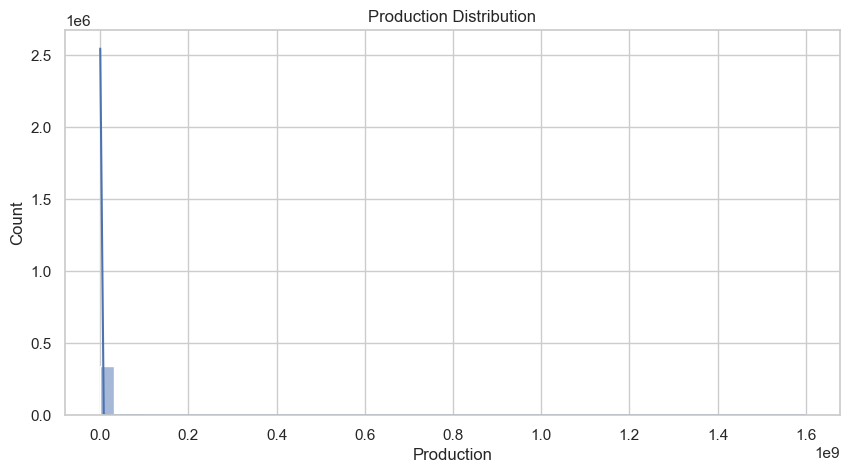

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(

    master["Production"],

    bins=50,

    kde=True

)

plt.title("Production Distribution")

plt.show()

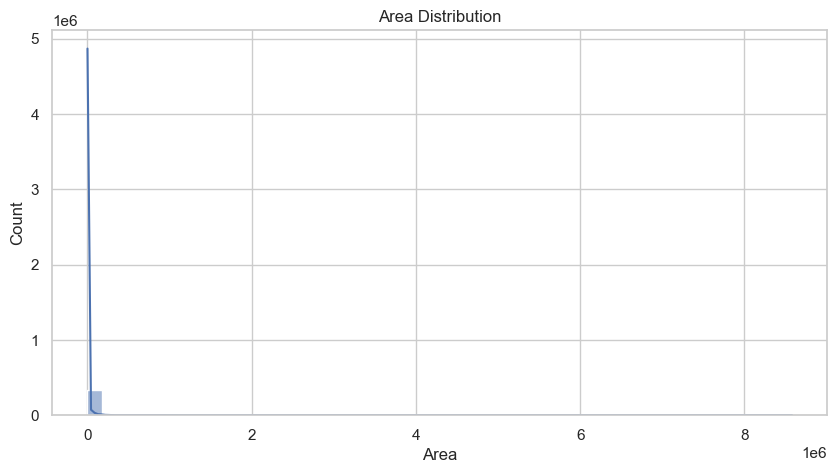

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(

    master["Area"],

    bins=50,

    kde=True

)

plt.title("Area Distribution")

plt.show()

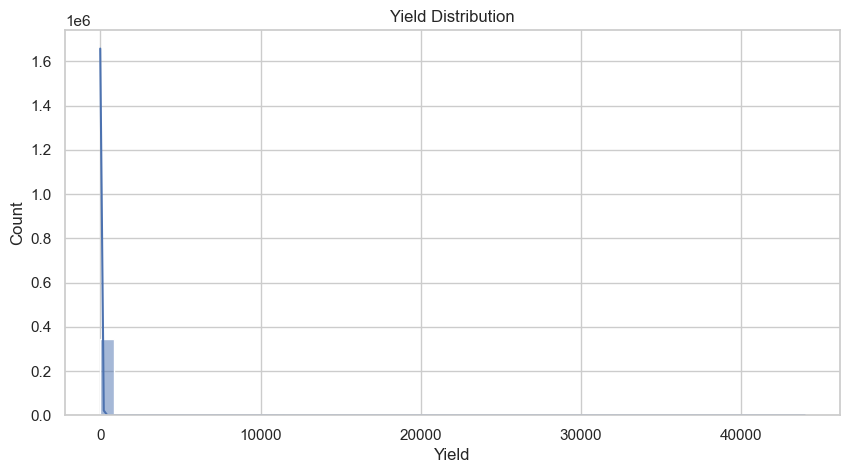

In [29]:
plt.figure(figsize=(10,5))

sns.histplot(

    master["Yield"],

    bins=50,

    kde=True

)

plt.title("Yield Distribution")

plt.show()

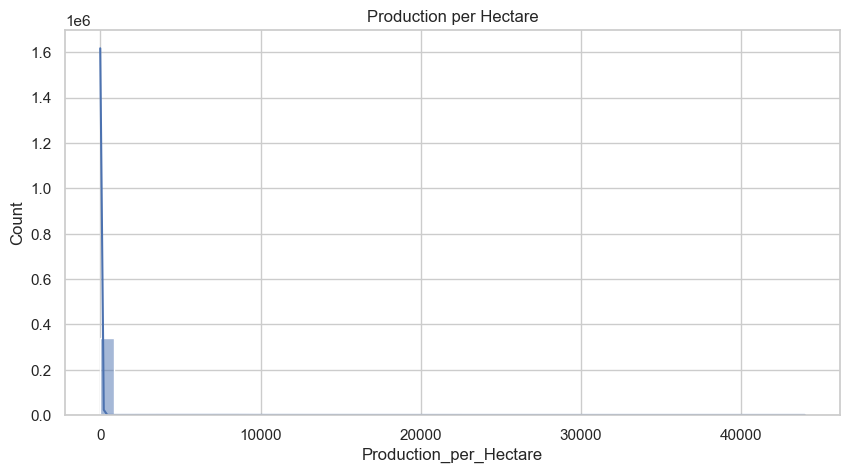

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(

    master["Production_per_Hectare"],

    bins=50,

    kde=True

)

plt.title("Production per Hectare")

plt.show()

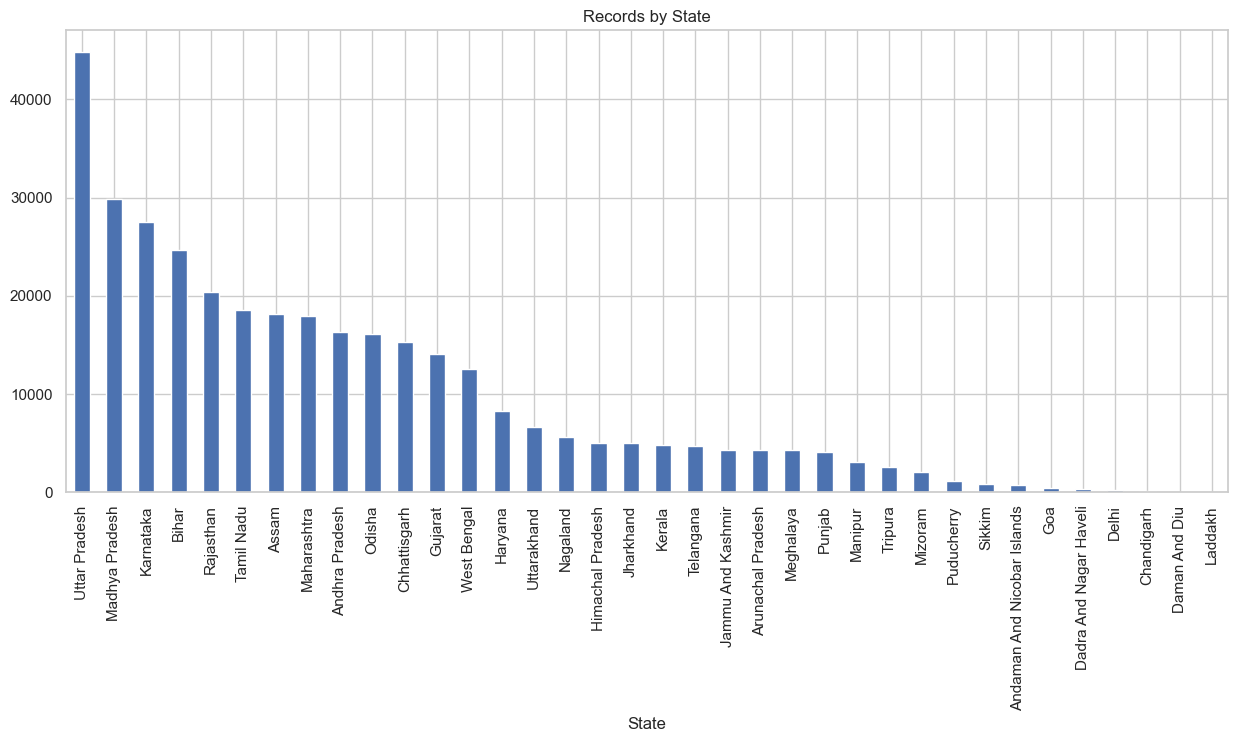

In [31]:
plt.figure(figsize=(15,6))

master["State"]\
.value_counts()\
.plot(kind="bar")

plt.title("Records by State")

plt.show()

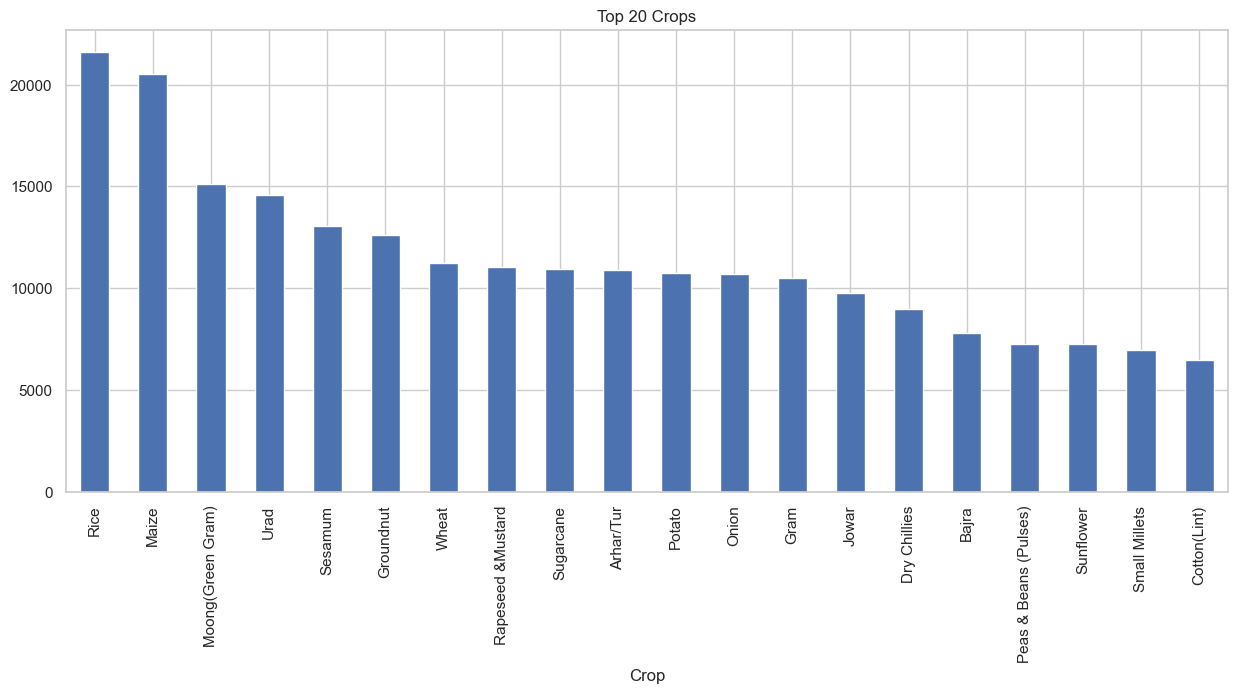

In [32]:
plt.figure(figsize=(15,6))

master["Crop"]\
.value_counts()\
.head(20)\
.plot(kind="bar")

plt.title("Top 20 Crops")

plt.show()

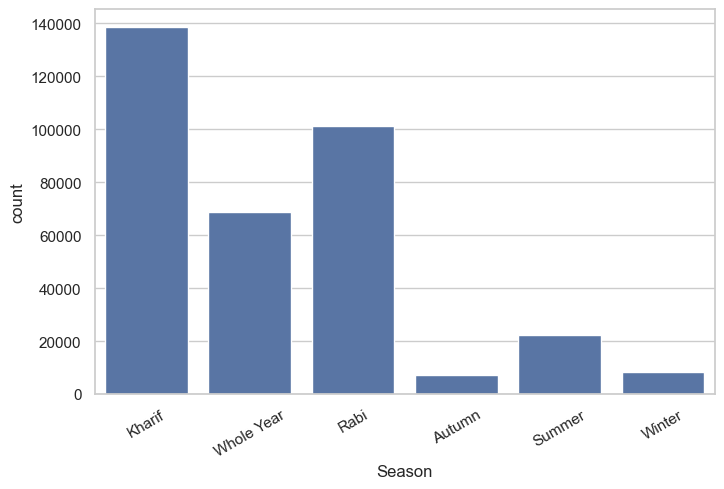

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=master,

    x="Season"

)

plt.xticks(rotation=30)

plt.show()

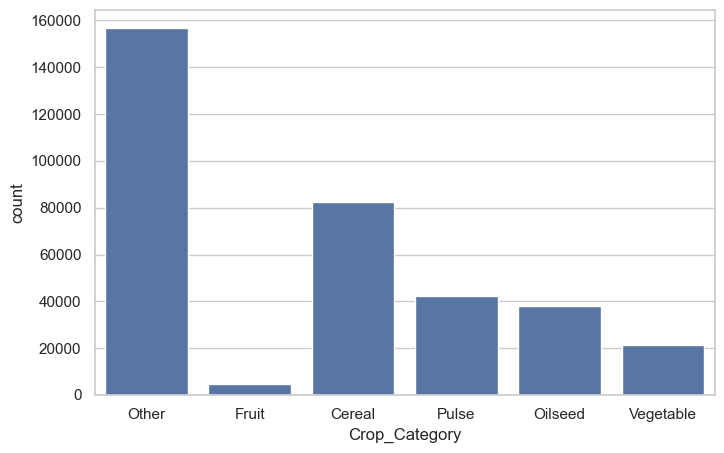

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=master,

    x="Crop_Category"

)

plt.show()

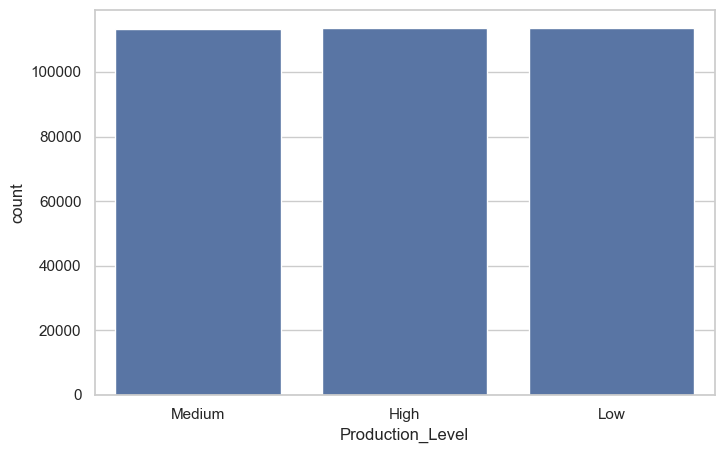

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=master,

    x="Production_Level"

)

plt.show()

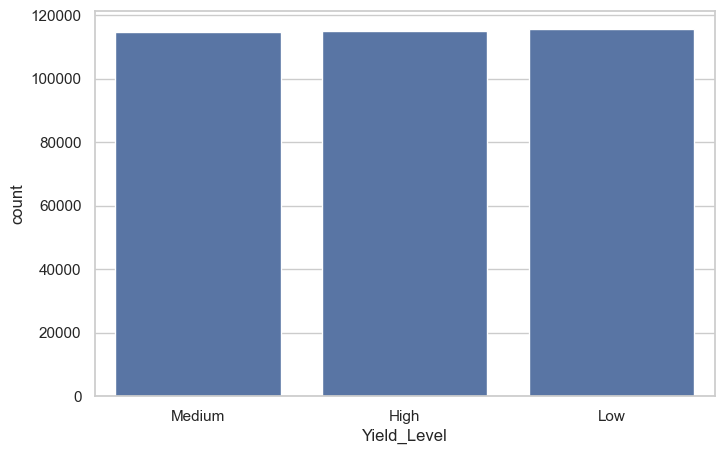

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=master,

    x="Yield_Level"

)

plt.show()

In [37]:
master["Weather_Data_Available"].value_counts()

Weather_Data_Available
True     323787
False     21587
Name: count, dtype: int64

In [38]:
master["Soil_Data_Available"].value_counts()

Soil_Data_Available
True     323787
False     21587
Name: count, dtype: int64

In [39]:
master.memory_usage(deep=True).sum()/1024**2

np.float64(319.2212600708008)

In [40]:
master.duplicated().sum()

np.int64(0)

In [41]:
print("="*70)
print("PHASE 7A VERIFICATION")
print("="*70)

print()

print("Dataset Shape")
print(master.shape)

print()

print("Numeric Features")
print(len(master.select_dtypes(include=np.number).columns))

print()

print("Categorical Features")
print(len(master.select_dtypes(include="object").columns))

print()

summary=pd.DataFrame({

    "EDA Step":[

        "Overview",

        "Statistics",

        "Missing Values",

        "Distribution Analysis",

        "Categorical Analysis",

        "Verification"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "PASS"

    ]

})

display(summary)

PHASE 7A VERIFICATION

Dataset Shape
(345374, 40)

Numeric Features
24

Categorical Features
14



,EDA Step,Status
0,Overview,Completed
1,Statistics,Completed
2,Missing Values,Completed
3,Distribution Analysis,Completed
4,Categorical Analysis,Completed
5,Verification,PASS


In [42]:
# PHASE 7B — Relationship Analysis & Correlation

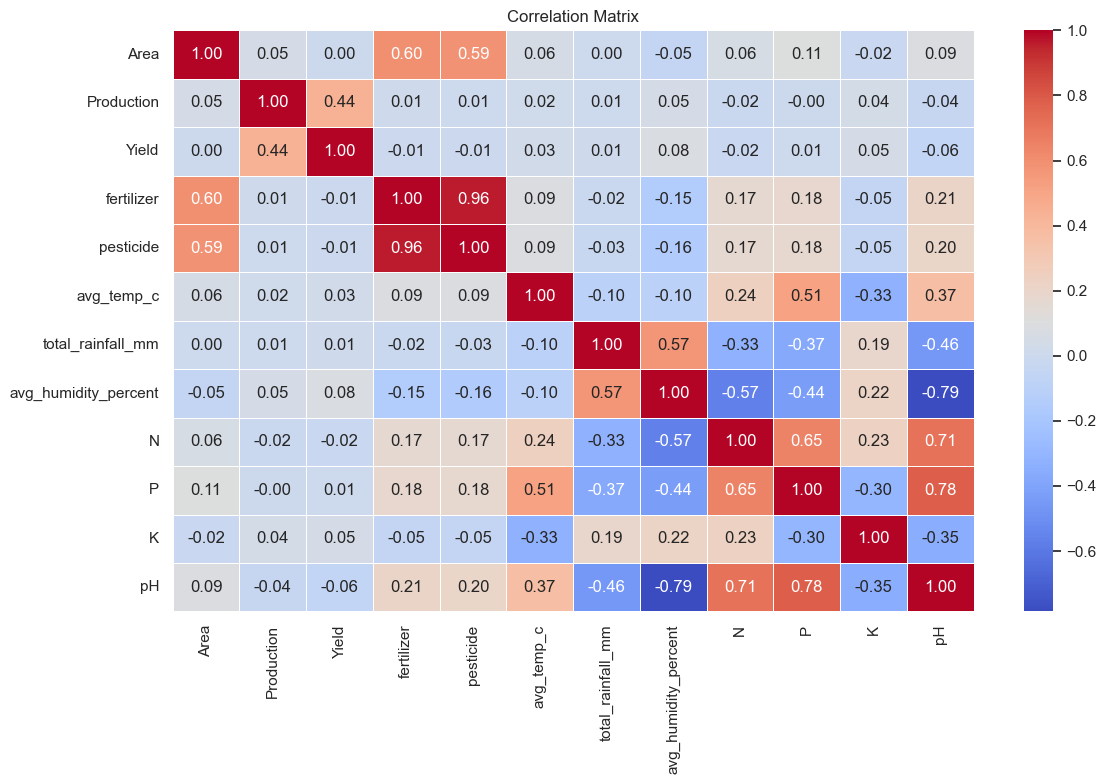

In [43]:
corr_columns = [
    "Area",
    "Production",
    "Yield",
    "fertilizer",
    "pesticide",
    "avg_temp_c",
    "total_rainfall_mm",
    "avg_humidity_percent",
    "N",
    "P",
    "K",
    "pH"
]

corr = master[corr_columns].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

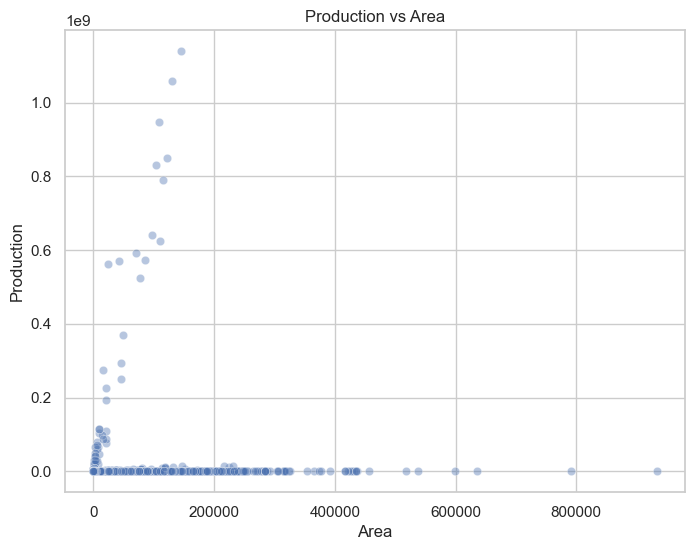

In [44]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=master.sample(10000, random_state=42),
    x="Area",
    y="Production",
    alpha=0.4
)

plt.title("Production vs Area")
plt.show()

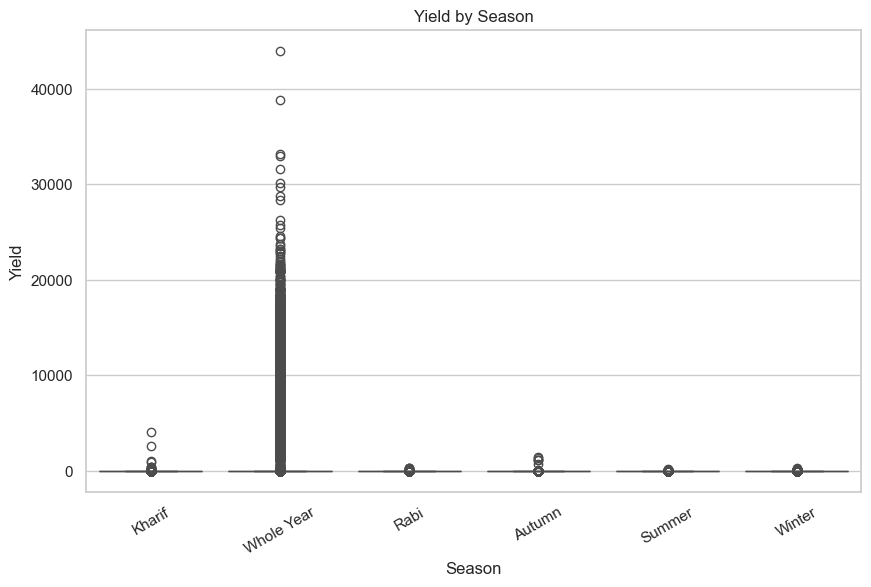

In [45]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=master,
    x="Season",
    y="Yield"
)

plt.xticks(rotation=30)

plt.title("Yield by Season")

plt.show()

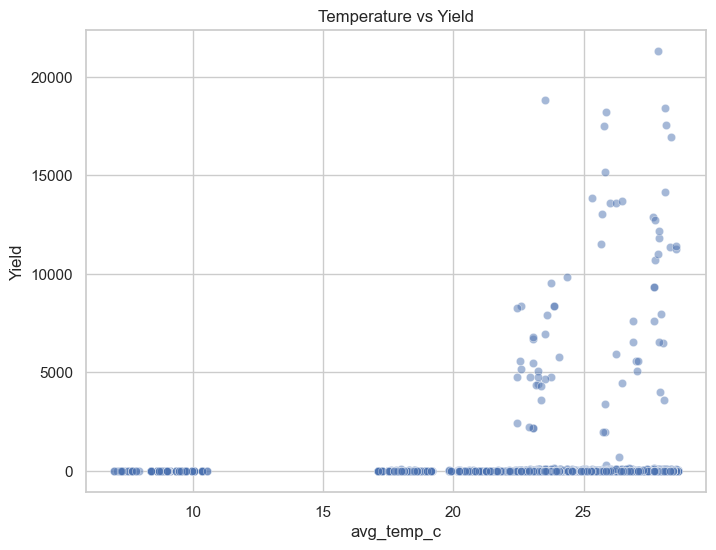

In [46]:
weather = master.dropna(subset=["avg_temp_c"])

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=weather.sample(min(8000,len(weather)), random_state=42),
    x="avg_temp_c",
    y="Yield",
    alpha=0.5
)

plt.title("Temperature vs Yield")

plt.show()

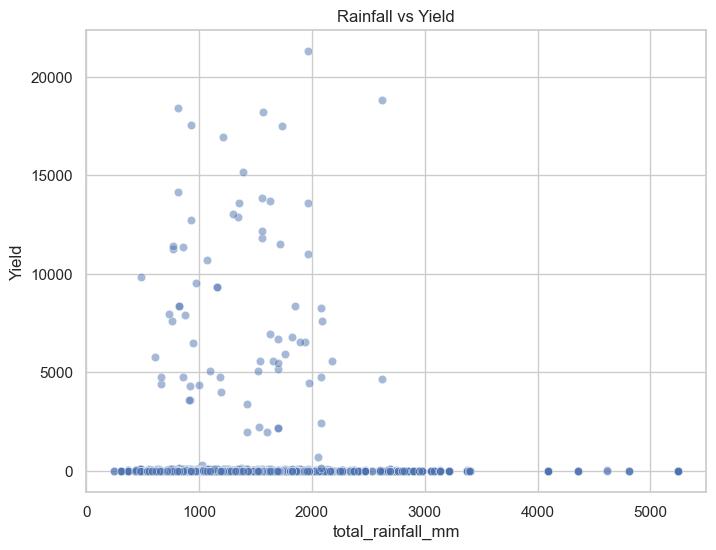

In [47]:
weather = master.dropna(subset=["total_rainfall_mm"])

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=weather.sample(min(8000,len(weather)), random_state=42),
    x="total_rainfall_mm",
    y="Yield",
    alpha=0.5
)

plt.title("Rainfall vs Yield")

plt.show()

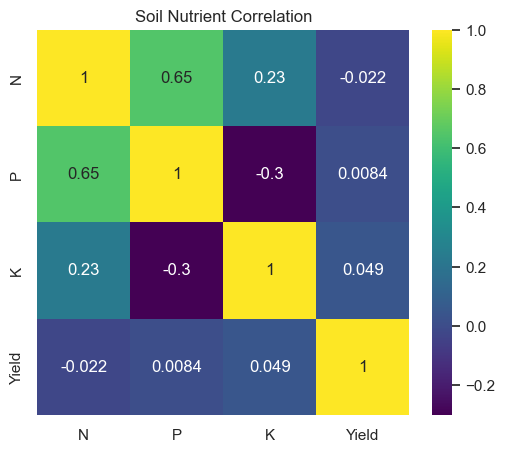

In [48]:
soil = master.dropna(subset=["N","P","K"])

soil_corr = soil[["N","P","K","Yield"]].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    soil_corr,
    annot=True,
    cmap="viridis"
)

plt.title("Soil Nutrient Correlation")

plt.show()

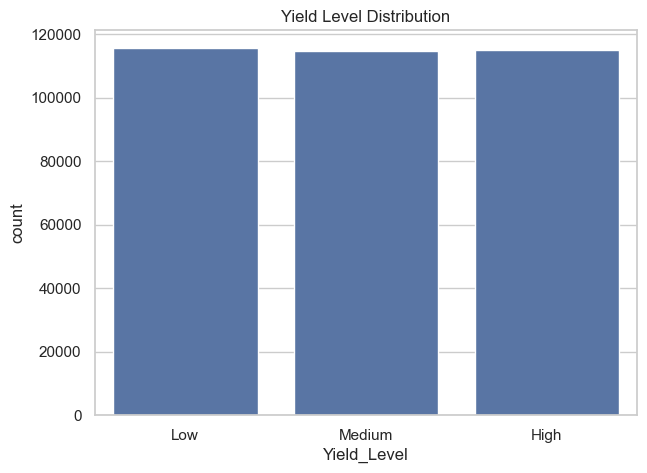

In [49]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=master,
    x="Yield_Level",
    order=["Low","Medium","High"]
)

plt.title("Yield Level Distribution")

plt.show()

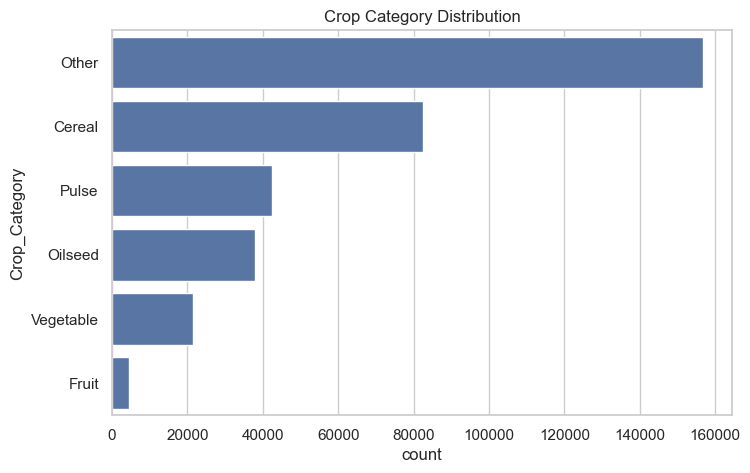

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=master,
    y="Crop_Category",
    order=master["Crop_Category"].value_counts().index
)

plt.title("Crop Category Distribution")

plt.show()

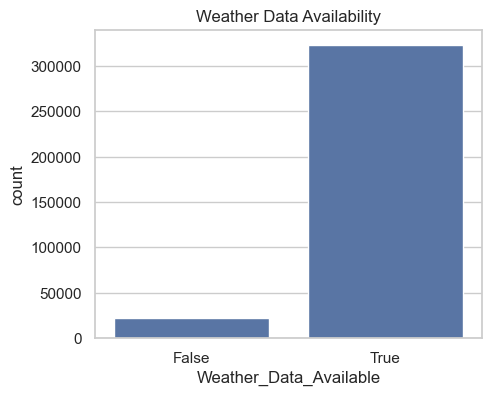

In [51]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=master,
    x="Weather_Data_Available"
)

plt.title("Weather Data Availability")

plt.show()

In [52]:
print("="*65)
print("PHASE 7B VERIFICATION")
print("="*65)

summary = pd.DataFrame({
    "Analysis":[
        "Correlation",
        "Scatterplots",
        "Season Analysis",
        "Weather Analysis",
        "Soil Analysis",
        "Category Analysis",
        "Verification"
    ],
    "Status":[
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "PASS"
    ]
})

display(summary)

PHASE 7B VERIFICATION


,Analysis,Status
0,Correlation,Completed
1,Scatterplots,Completed
2,Season Analysis,Completed
3,Weather Analysis,Completed
4,Soil Analysis,Completed
5,Category Analysis,Completed
6,Verification,PASS
